In [1]:
# Check Python version
!python --version

Python 3.13.9


In [750]:
import numpy as np
import pandas as pd
import os
import json
import pickle
import random

from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [751]:
# Set CUDA_VISIBLE_DEVICES
seed = 42
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)

In [766]:
def load_docs(df_name):
    df = pd.read_parquet(f'data/processed/parquet/{df_name}_text.parquet')
    docs = df['text'].tolist()

    return docs

In [776]:
# 2. Load your topics dictionary
# Format expected: {topic_id: [('word1', 0.9), ('word2', 0.8), ...]}

df_name = 'reuters'
docs = load_docs(df_name)
len(docs)


10252

In [768]:
def load_infos(df_name, model_name):
    general_path = f"saved/{df_name}_{model_name}"

    dict_path = f"{general_path}/{df_name}_topics_dict.pkl"

    with open(dict_path, "rb") as f:
        topics_dict = pickle.load(f)

    final_topics_path = f"{general_path}/{df_name}_final_topics.pkl"

    with open(final_topics_path, "rb") as f:
        final_topics = pickle.load(f)

    word_list_path = f"{general_path}/{df_name}_topics_word_list.json"

    with open(word_list_path, "r") as f:
        topics_word_list = json.load(f)


    return topics_dict, final_topics, topics_word_list

In [777]:
model_name = 'bertopic'

topics_dict, final_topics, topics_word_list = load_infos(df_name, model_name)

In [778]:
random_ids = np.load(f"saved/{df_name}_random_samples.npy")

for id in random_ids:
    if len(final_topics[id]) == 0:
        print(id)

In [779]:
def extract_doc_and_topics(chosen_id, docs, final_topics, topics_word_list):
    document = docs[chosen_id]
    topics_id = [t for t, prob in final_topics[chosen_id]]
    topics = []

    for id in topics_id:
        topics.append(topics_word_list[id])
    
    topic_text = ""

    for i in range(len(topics)):
        topic_text += f"["
        topic_text += f"{topics[i]}"
        topic_text += "]"

        if i < len(topics) - 1:
            topic_text += ", "
        else:
            topic_text += "."
    
    num_topics = len(topics)

        
    return document, topic_text, num_topics

In [780]:
def extract_only_topics(chosen_id, df_name, model_name):
    topics_dict, final_topics, topics_word_list = load_infos(df_name, model_name)
    topics_id = [t for t, prob in final_topics[chosen_id]]
    topics = {}

    for id in topics_id:
        topics[id] = topics_dict[id]

    return topics

In [781]:
chosen_id = 0
document, topic_text, num_topics = extract_doc_and_topics(chosen_id, docs, final_topics, topics_word_list)

print(document)
print(topic_text)

Showers continued throughout the week in the Bahia cocoa zone, alleviating the drought since early January and improving prospects for the coming temporao, although normal humidity levels have not been restored, Comissaria Smith said in its weekly review. The dry period means the temporao will be late this year. Arrivals for the week ended February 22 were 155,221 bags of 60 kilos making a cumulative total for the season of 5.93 mln against 5.81 at the same stage last year. Again it seems that cocoa delivered earlier on consignment was included in the arrivals figures. Comissaria Smith said there is still some doubt as to how much old crop cocoa is still available as harvesting has practically come to an end. With total Bahia crop estimates around 6.4 mln bags and sales standing at almost 6.2 mln there are a few hundred thousand bags still in the hands of farmers, middlemen, exporters and processors. There are doubts as to how much of this cocoa would be fit for export as shippers are 

In [782]:
general_path = f"saved/{df_name}_{model_name}"
evaluation_results_new_path = f"{general_path}/{df_name}_evaluation_results_new.json"

with open(evaluation_results_new_path, "r") as f:
    evaluation_results = json.load(f)
    
evaluation_results[:5]


[{'Q1': False, 'Q2': True, 'Q3': True, 'Q4': 4},
 {'Q1': False, 'Q2': False, 'Q3': False, 'Q4': 2},
 {'Q1': False, 'Q2': False, 'Q3': False, 'Q4': 2},
 {'Q1': False, 'Q2': False, 'Q3': False, 'Q4': 2},
 {'Q1': True, 'Q2': True, 'Q3': False, 'Q4': 5}]

In [783]:
samples = []

for i in range(len(evaluation_results)):
    if evaluation_results[i]['Q1'] == True and evaluation_results[i]['Q2'] == True and evaluation_results[i]['Q3']==True:
        if evaluation_results[i]['Q4'] >= 4:
            samples.append(i)

print(samples)


[23, 37, 53, 66, 72, 103, 104, 163, 194, 203, 207, 212, 232, 245, 247, 256, 267, 272, 274, 319, 323, 340, 355, 408, 439, 469, 481, 501, 503, 513, 527, 533, 584, 601, 622, 646, 691, 716, 762, 772, 783, 799, 826, 827, 828, 833, 858, 861, 862, 867, 880, 911, 915, 937, 938, 950, 968, 974]


In [784]:
more_topics = []

for i in range(len(samples)):
    idx = random_ids[samples[i]]
    document, topic_text, num_topics = extract_doc_and_topics(idx, docs, final_topics, topics_word_list)

    if(num_topics) >= 4:
        more_topics.append(samples[i])

print(more_topics)

[772]


In [785]:
chosen_id = 772

idx = random_ids[chosen_id]
document, topic_text, num_topics = extract_doc_and_topics(idx, docs, final_topics, topics_word_list)
evaluation = evaluation_results[chosen_id]

total_text = ""
total_text += f"{document} \n\n"
total_text += f"{topic_text} \n\n"
total_text += f"{evaluation}"

print(total_text)

The Commodity Credit Corporation (CCC) has approved an additional 84.0 mln dlrs in credit guarantees for sales of U.S. agricultural products to Algeria for fiscal year 1987 under the Export Credit Guarantee Program (GSM-102), the U.S. Agriculture Department said. The department said the additional guarantees provide up to 31.0 mln dlrs in coverage for sales of protein meals, 9.0 mln dlrs for tallow, and 44.0 mln dlrs for vegetable oils. The latest guarantees increase the cumulative fiscal 1987 program for sales of U.S. agricultural products to Algeria to 464.0 mln dlrs from 380.0, it said. To be eligible for the credit guarantees, all sales must be registered with the CCC by September 30, and shipments completed by December 31, 1987, it said. 

[fiscal commodity credit redemptions sales corporation usda export guarantees agriculture], [stocks credit commodities corporation bonuses commodity conagra bonus bids inventory], [liquidity interbank shortfall market bank sterling money amounts

In [786]:
with open(f'{df_name}_{model_name}_{chosen_id}.txt', 'w') as output:
    output.write(total_text)

In [787]:
df_name_topic = 'reuters'

model_name_topic = 'bertopic'

saved_path = 'samples/true-true-true'

In [788]:
random_ids_topic = np.load(f"saved/{df_name_topic}_random_samples.npy")

In [789]:
idx_topic = 772
raw_topics = extract_only_topics(random_ids_topic[idx_topic], df_name_topic, model_name_topic)

raw_topics

{np.int64(102): [('fiscal', np.float32(0.7465239)),
  ('commodity', np.float32(0.7284391)),
  ('credit', np.float32(0.7270782)),
  ('redemptions', np.float32(0.71017456)),
  ('sales', np.float32(0.7043135)),
  ('corporation', np.float32(0.6997067)),
  ('usda', np.float32(0.69963753)),
  ('export', np.float32(0.68199563)),
  ('guarantees', np.float32(0.6801763)),
  ('agriculture', np.float32(0.6782944))],
 np.int64(109): [('stocks', np.float32(0.8031511)),
  ('credit', np.float32(0.7021383)),
  ('commodities', np.float32(0.69492847)),
  ('corporation', np.float32(0.6856754)),
  ('bonuses', np.float32(0.6824495)),
  ('commodity', np.float32(0.6568247)),
  ('conagra', np.float32(0.65052885)),
  ('bonus', np.float32(0.64969146)),
  ('bids', np.float32(0.64861125)),
  ('inventory', np.float32(0.6387534))],
 np.int64(111): [('liquidity', np.float32(0.7659052)),
  ('interbank', np.float32(0.72925997)),
  ('shortfall', np.float32(0.71542645)),
  ('market', np.float32(0.6950775)),
  ('bank', np

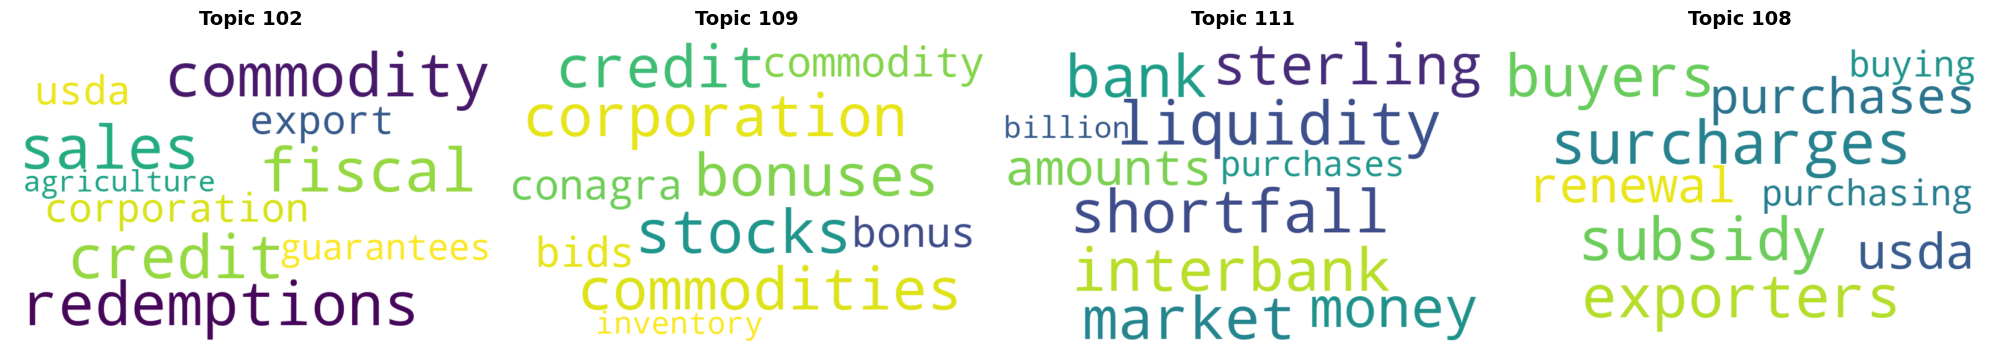

In [ ]:
# Dynamically find out how many topics we need to plot
num_topics = len(raw_topics)

# Create a grid of subplots (1 row, N columns)
# Dnamically scale the width
fig, axes = plt.subplots(nrows=1, ncols=num_topics, figsize=(5 * num_topics, 5))

# Handle the edge case if the dictionary only has 1 topic
if num_topics == 1:
    axes = [axes]

# Loop through the dictionary items and plot each cloud
for idx, (topic_id, word_tuples) in enumerate(raw_topics.items()):
    
    # Convert the list of tuples into a clean dictionary of {word: weight}
    # e.g., {'self-supervised': 0.76234156, ...}
    frequencies = {word: float(weight) for word, weight in word_tuples}
    
    # Generate the WordCloud object using the actual mathematical weights
    wordcloud = WordCloud(
        width=800, 
        height=500, 
        background_color='white',
        colormap='viridis',
        prefer_horizontal=1,
        relative_scaling=0.2,
        max_font_size=100,
        min_font_size=40,
    ).generate_from_frequencies(frequencies)
    
    # Plot onto the specific subfigure axis
    ax = axes[idx]
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f"Topic {topic_id}", fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')

# Clean up spacing and display
plt.tight_layout()

plt.savefig(
    f"{saved_path}/{df_name_topic}_{model_name_topic}_{idx_topic}.png",    # The file name and extension (.png, .pdf, .svg)
    dpi=300,                   # 300 DPI is the standard for high-quality/print resolution
    bbox_inches='tight',       # Ensures the title and edges aren't cut off
    transparent=False          # Set to True for transparent background
)
plt.show()

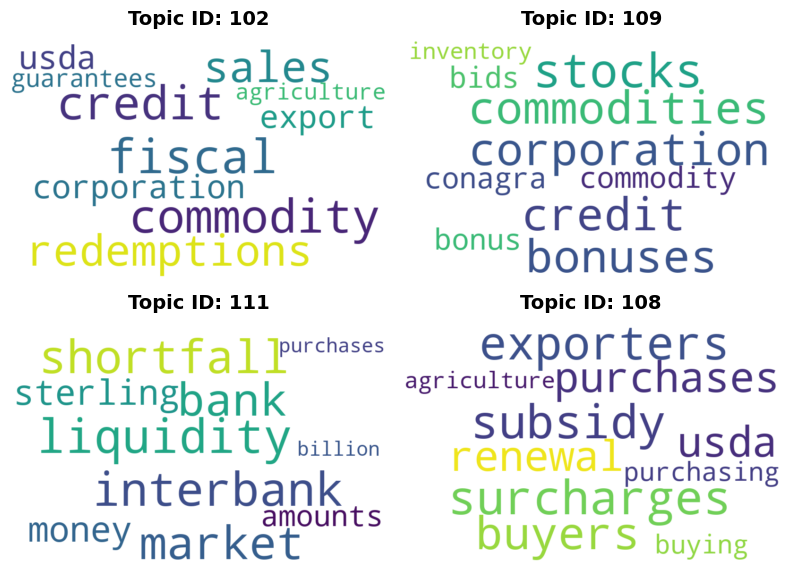

In [ ]:

# Initialize a 2x2 grid. 
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6))

# Loop through dictionary
for idx, (topic_id, word_tuples) in enumerate(raw_topics.items()):
    
    # Calculate the 2D grid coordinates (row and column) from a 1D index
    row = idx // 2  # 0 for first two, 1 for last two
    col = idx % 2   # 0 for left column, 1 for right column
    
    frequencies = {word: float(weight) for word, weight in word_tuples}
    
    # Generate the WordCloud
    wordcloud = WordCloud(
        width=800, 
        height=500, 
        background_color='white',
        colormap='viridis',
        prefer_horizontal=1,
        relative_scaling=0.3,
        max_font_size=100,
        min_font_size=40,
    ).generate_from_frequencies(frequencies)
    
    # Target the specific cell in the 2D matrix
    ax = axes[row, col]
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f"Topic ID: {topic_id}", fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')

# Clean up layout and save automatically
plt.tight_layout()
plt.savefig("topics_2x2_grid.png", dpi=300, bbox_inches='tight')
plt.show()

In [621]:
# wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=10, colormap='cividis').generate(topic_text)

# plt.figure(figsize=(10, 5))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis('off')
# plt.title("Word Cloud")
# plt.show()